In [1]:
import numpy as np

with open("full_0.0seconds.dat") as f:
    header = f.readline()
    print(header)

params = [
    "total_mass",
    "mass_ratio",
    "spin1_magnitude",
    "spin2_magnitude",
    "tilt1",
    "tilt2",
    "phi12",
    "theta_jn",
    "inclination",
    "luminosity_distance",
    "right_ascension",
    "declination",
    "polarization",
    "phase",
    "geocenter_time"
]

with open("full_0.0seconds.dat") as f:
          header = f.readline().split()

cols = [header.index(p) for p in params]

data = np.loadtxt(
    "full_0.0seconds.dat",
    skiprows=1,
    unpack=True,
    usecols=cols
    )

total_mass mass_ratio luminosity_distance inclination spin1_magnitude spin2_magnitude declination phase right_ascension polarization spin1_x spin1_y spin1_z spin2_x spin2_y spin2_z geocenter_time theta_jn phi_jl tilt1 tilt2 phi12 ln_posterior ln_prior ln_likelihood network_optimal_SNR network_matched_filter_SNR H1_optimal_SNR L1_optimal_SNR V1_optimal_SNR H1_matched_filter_SNR L1_matched_filter_SNR V1_matched_filter_SNR



In [2]:
print(cols)

[0, 1, 4, 5, 19, 20, 21, 17, 3, 2, 8, 6, 9, 7, 16]


In [3]:
files = {
    "0.0": "pre_results/full_0.0seconds.dat",
    "-0.05": "pre_results/pre_-0.05seconds.dat",
    "-0.01": "pre_results/pre_-0.01seconds.dat",
    "0.01": "pre_results/pre_0.01seconds.dat",
    "0.04": "pre_results/pre_0.04seconds.dat",
    "0.05": "pre_results/pre_0.05seconds.dat"
}

data = {}

for key, file in files.items():
    data[key] = np.loadtxt(
        file, skiprows=1,
        unpack=True,
        usecols=cols
    )

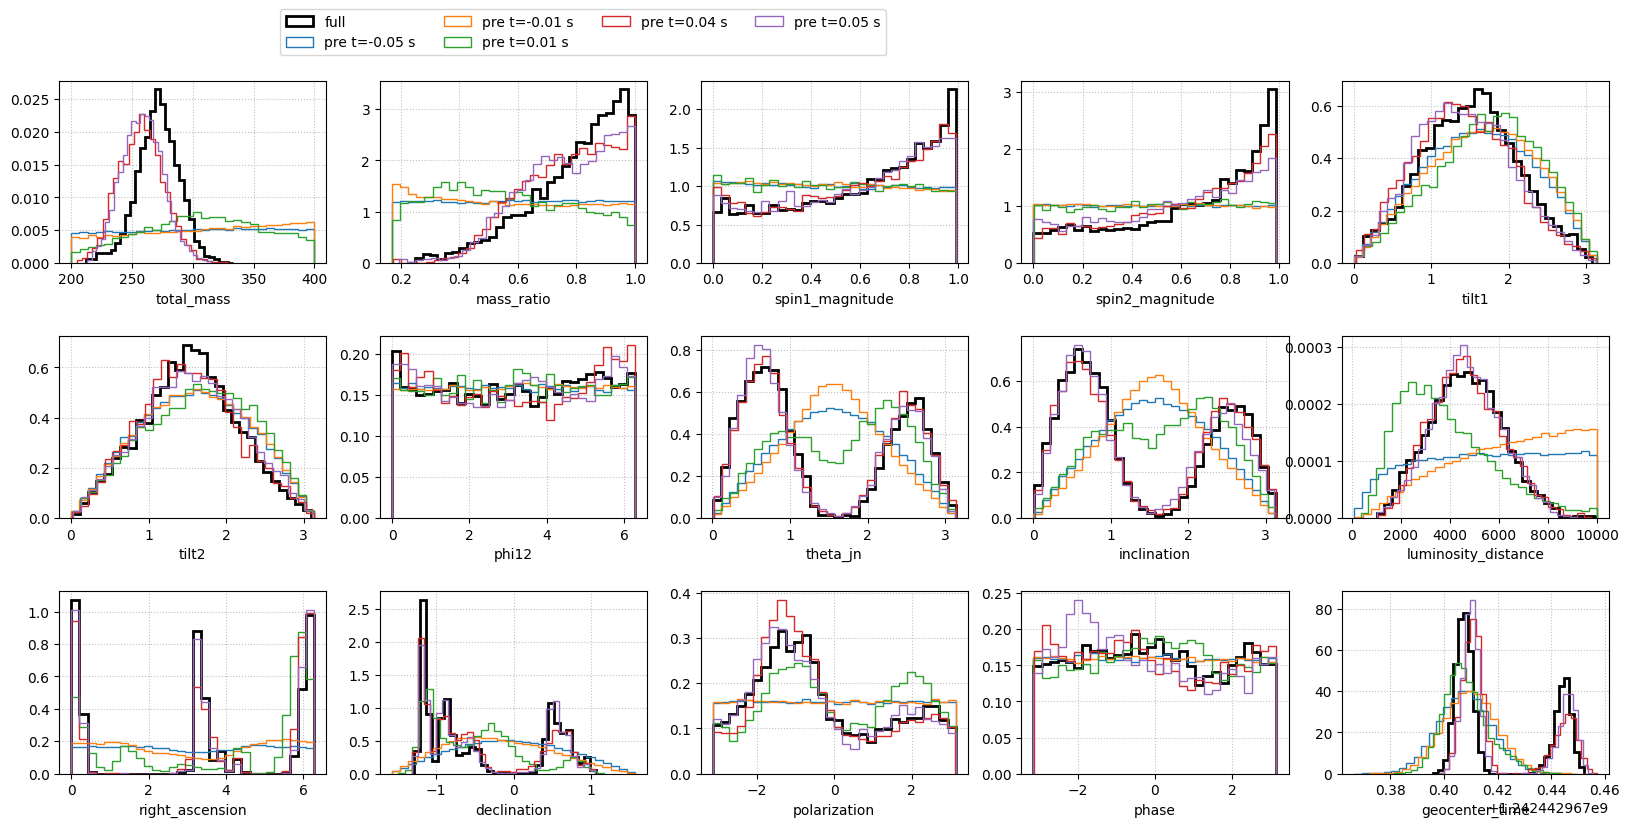

In [5]:
import matplotlib.pyplot as plt

params_to_plot = [
    'total_mass','mass_ratio','spin1_magnitude','spin2_magnitude',
    'tilt1','tilt2','phi12','theta_jn','inclination','luminosity_distance',
    'right_ascension','declination','polarization','phase','geocenter_time'
]

param_index = {p:i for i,p in enumerate(params_to_plot)}

fig, axes = plt.subplots(3,5,figsize=(20,9))

hist_kws = dict(density=True, histtype='step', bins=30)

for ax, p in zip(axes.flatten(), params_to_plot):

    i = param_index[p]

    ax.hist(data["0.0"][i], **hist_kws, lw=2, color='k', label='full')
    ax.hist(data["-0.05"][i], **hist_kws, color='C0', label='pre t=-0.05 s')
    ax.hist(data["-0.01"][i], **hist_kws, color='C1', label='pre t=-0.01 s')
    ax.hist(data["0.01"] [i], **hist_kws, color='C2', label='pre t=0.01 s')
    ax.hist(data["0.04"][i], **hist_kws, color='C3', label='pre t=0.04 s')
    ax.hist(data["0.05"][i], **hist_kws, color='C4', label='pre t=0.05 s')

    ax.set_xlabel(p)
    ax.grid(color='silver', ls=':')

axes[0][0].legend(ncols=4, loc='lower left', bbox_to_anchor=(0.8,1.1))

plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

(array([  92.,  174.,  515., 1432., 2420., 2225., 1308.,  441.,   86.,
          11.]),
 array([212.08408894, 224.20296521, 236.32184148, 248.44071775,
        260.55959402, 272.6784703 , 284.79734657, 296.91622284,
        309.03509911, 321.15397538, 333.27285165]),
 <BarContainer object of 10 artists>)

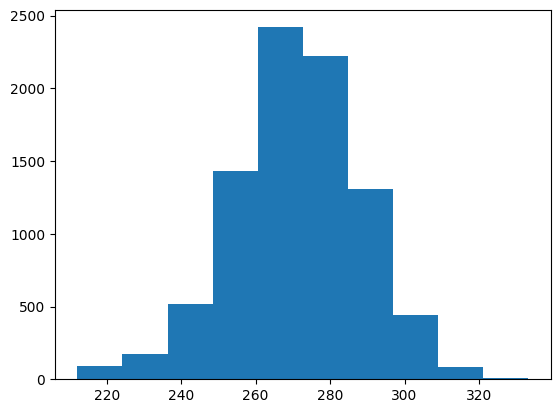

In [12]:
plt.hist(data["0.0"][0,:])